# Import libraries

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import os
# visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
#geographic libraires
import folium
import json
import geopandas as gpd
#machine learning
import sklearn
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# import dataframe

In [5]:
#Identify path 
data_path= '../02 Data/'
vis_path= '../04 Analysis/'

In [12]:
# import geo merged dataframe
df=pd.read_pickle(os.path.join(data_path,'Prepared Data','health_geo_merged.pkl'))

# Data Cleaning

In [13]:
df.columns

Index(['country', 'geometry', 'country_name', 'Time', 'hospital_stay',
       'mri_units', 'ct_scanners', 'hospital_beds'],
      dtype='object')

In [14]:
df.head(20)

,country,geometry,country_name,Time,hospital_stay,mri_units,ct_scanners,hospital_beds
0,AUS,"MULTIPOLYGON (((145.39798 -40.79255, 146.36412...",Australia,1992,6.6,1.43,16.71,1.43
1,AUS,"MULTIPOLYGON (((145.39798 -40.79255, 146.36412...",Australia,1994,6.4,2.36,18.48,2.36
2,AUS,"MULTIPOLYGON (((145.39798 -40.79255, 146.36412...",Australia,1995,6.5,2.89,20.55,2.89
3,AUS,"MULTIPOLYGON (((145.39798 -40.79255, 146.36412...",Australia,1996,6.4,2.96,21.95,2.96
4,AUS,"MULTIPOLYGON (((145.39798 -40.79255, 146.36412...",Australia,1997,6.2,3.53,23.34,3.53
5,AUS,"MULTIPOLYGON (((145.39798 -40.79255, 146.36412...",Australia,1998,6.1,4.51,24.18,4.51
6,AUS,"MULTIPOLYGON (((145.39798 -40.79255, 146.36412...",Australia,1999,6.2,6.01,25.52,6.01
7,AUS,"MULTIPOLYGON (((145.39798 -40.79255, 146.36412...",Australia,2000,6.1,3.52,26.28,3.52
8,AUS,"MULTIPOLYGON (((145.39798 -40.79255, 146.36412...",Australia,2001,6.2,3.79,29.05,3.79
9,AUS,"MULTIPOLYGON (((145.39798 -40.79255, 146.36412...",Australia,2002,6.2,3.74,34.37,3.74


In [15]:
df.shape

(518, 8)

In [16]:
# check for duplicates again
df.isnull().sum()

country          0
geometry         0
country_name     0
Time             0
hospital_stay    0
mri_units        0
ct_scanners      0
hospital_beds    0
dtype: int64

# Scatter plot

In [17]:
df.columns

Index(['country', 'geometry', 'country_name', 'Time', 'hospital_stay',
       'mri_units', 'ct_scanners', 'hospital_beds'],
      dtype='object')

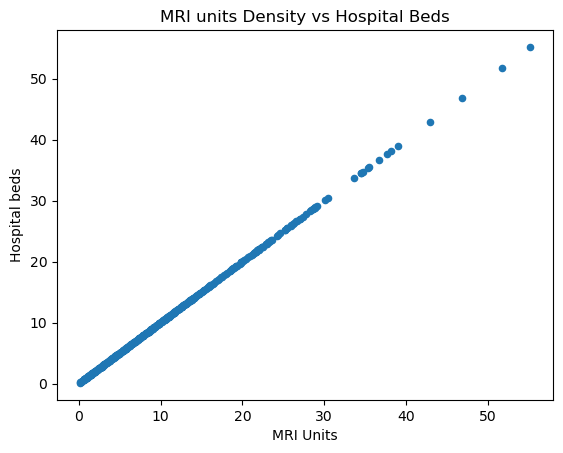

In [25]:
# scatter plot for mri_units and hospital_beds
df.plot(kind='scatter',x='mri_units', y='hospital_beds') 
# The style option creates a scatterplot; without it, we only have lines.
plt.title('MRI units Density vs Hospital Beds')  
plt.xlabel('MRI Units')  
plt.ylabel('Hospital beds')  
plt.show()

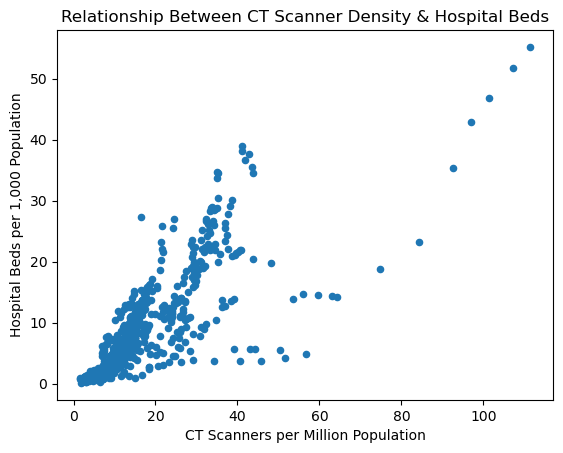

In [63]:
# scatter plot for mri_units and hospital_beds
ct_hospital_stay=df.plot(kind='scatter',x='ct_scanners', y='hospital_beds') 
# The style option creates a scatterplot; without it, we only have lines.
plt.title("Relationship Between CT Scanner Density & Hospital Beds")
plt.xlabel("CT Scanners per Million Population")
plt.ylabel("Hospital Beds per 1,000 Population")
plt.show()

In [57]:
#export
ct_hospital_stay.figure.savefig(os.path.join(vis_path,'Visuals','Update ct scanner beds'), bbox_inches='tight')

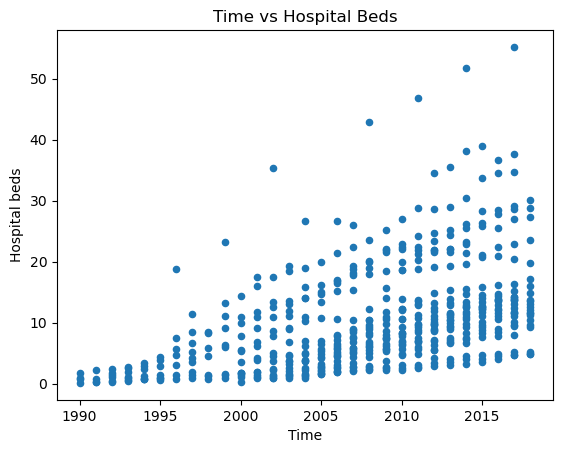

In [59]:
# scatter plot for mri_units and hospital_beds
time_beds=df.plot(kind='scatter',x='Time', y='hospital_beds') 
# The style option creates a scatterplot; without it, we only have lines.
plt.title('Time vs Hospital Beds')  
plt.xlabel('Time')  
plt.ylabel('Hospital beds')  
plt.show()

In [60]:
#export
time_beds.figure.savefig(os.path.join(vis_path,'Visuals','Update time beds'), bbox_inches='tight')

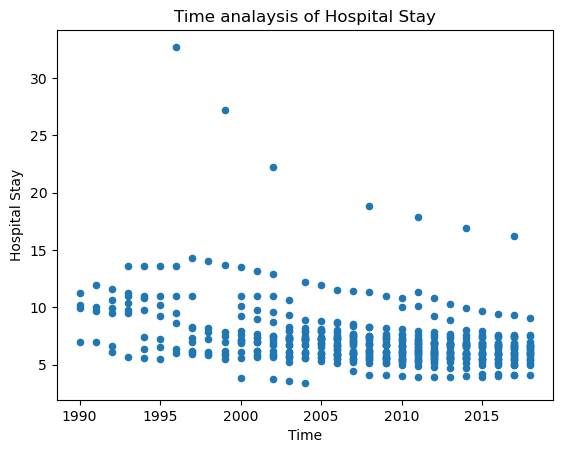

In [61]:
# scatter plot for mri_units and hospital_beds
time_stay=df.plot(kind='scatter',x='Time', y='hospital_stay') 
# The style option creates a scatterplot; without it, we only have lines.
plt.title('Time analaysis of Hospital Stay')  
plt.xlabel('Time')  
plt.ylabel('Hospital Stay')  
plt.show()

In [62]:
#export
time_stay.figure.savefig(os.path.join(vis_path,'Visuals','Update time stay'), bbox_inches='tight')

## Hypothesis:
In OECD nations, a higher density of diagnostic imaging units (MRI and CT scanners) is significantly associated with a long-term reduction in hospital bed capacity, suggesting a technological shift from inpatient-heavy care to rapid-diagnostic outpatient models.

In [64]:
# Reshape the variables into NumPy arrays and put them into separate objects.
# to run another regression analysis you need to updated theres X and y-> theyre currnetly linked to the regression analysis from below

X= df['ct_scanners'].values.reshape(-1,1)
y=df['hospital_beds'].values.reshape(-1,1)

In [32]:
X

array([[ 1.43],
       [ 2.36],
       [ 2.89],
       [ 2.96],
       [ 3.53],
       [ 4.51],
       [ 6.01],
       [ 3.52],
       [ 3.79],
       [ 3.74],
       [ 3.7 ],
       [ 3.76],
       [ 4.26],
       [ 4.89],
       [ 5.72],
       [ 5.67],
       [ 5.6 ],
       [ 5.5 ],
       [13.84],
       [14.65],
       [14.49],
       [14.3 ],
       [14.15],
       [ 7.54],
       [ 8.53],
       [ 8.52],
       [11.01],
       [10.98],
       [11.69],
       [13.36],
       [13.54],
       [15.91],
       [16.16],
       [16.81],
       [17.72],
       [18.03],
       [18.46],
       [18.65],
       [18.71],
       [19.1 ],
       [19.22],
       [19.66],
       [20.71],
       [22.43],
       [22.96],
       [23.53],
       [ 6.84],
       [ 7.  ],
       [ 6.97],
       [ 7.11],
       [ 7.53],
       [10.36],
       [10.65],
       [10.65],
       [10.69],
       [10.62],
       [10.84],
       [11.78],
       [11.71],
       [11.65],
       [11.6 ],
       [11.64],
       [

In [33]:
y

array([[ 1.43],
       [ 2.36],
       [ 2.89],
       [ 2.96],
       [ 3.53],
       [ 4.51],
       [ 6.01],
       [ 3.52],
       [ 3.79],
       [ 3.74],
       [ 3.7 ],
       [ 3.76],
       [ 4.26],
       [ 4.89],
       [ 5.72],
       [ 5.67],
       [ 5.6 ],
       [ 5.5 ],
       [13.84],
       [14.65],
       [14.49],
       [14.3 ],
       [14.15],
       [ 7.54],
       [ 8.53],
       [ 8.52],
       [11.01],
       [10.98],
       [11.69],
       [13.36],
       [13.54],
       [15.91],
       [16.16],
       [16.81],
       [17.72],
       [18.03],
       [18.46],
       [18.65],
       [18.71],
       [19.1 ],
       [19.22],
       [19.66],
       [20.71],
       [22.43],
       [22.96],
       [23.53],
       [ 6.84],
       [ 7.  ],
       [ 6.97],
       [ 7.11],
       [ 7.53],
       [10.36],
       [10.65],
       [10.65],
       [10.69],
       [10.62],
       [10.84],
       [11.78],
       [11.71],
       [11.65],
       [11.6 ],
       [11.64],
       [

In [65]:
# split data into a training ser and test set
X_train,X_test,y_train, y_test= train_test_split(X,y, test_size=0.3,random_state=0)

# Regression Analysis

In [66]:
# create a regression object
# This is the regression object, which will be fit onto the training set.
regression= LinearRegression()

In [67]:
# Fit the regression object onto the training set.

regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [68]:
# Predict the values of y using X.

y_predicted = regression.predict(X_test)

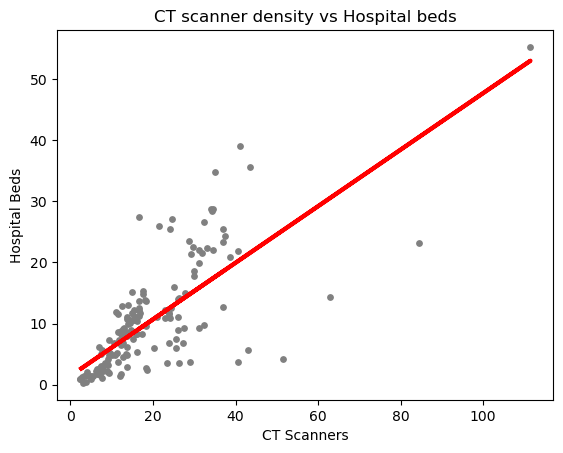

In [69]:
# Create a plot that shows the regression line from the model on the test set.

plot_test = plt
plot_test.scatter(X_test, y_test, color='gray', s = 15)
plot_test.plot(X_test, y_predicted, color='red', linewidth =3)
plot_test.title('CT scanner density vs Hospital beds')
plot_test.xlabel('CT Scanners')
plot_test.ylabel('Hospital Beds')
plot_test.show()

In [70]:
# Create objects that contain the model summary statistics.

rmse = mean_squared_error(y_test, y_predicted) # This is the mean squared error
r2 = r2_score(y_test, y_predicted) # This is the R2 score. 

In [71]:
# Print the model summary statistics. This is where you evaluate the performance of the model.

print('Slope:' ,regression.coef_)
print('Mean squared error: ', rmse)
print('R2 score: ', r2)

Slope: [[0.46210117]]
Mean squared error:  36.66295688867276
R2 score:  0.53438643689918


In [72]:
# Create a dataframe comparing the actual and predicted values of y.

data = pd.DataFrame({'Actual': y_test.flatten(), 'Predicted': y_predicted.flatten()})
data.head(30)

,Actual,Predicted
0,12.16,9.166138
1,21.39,14.896193
2,7.23,5.811284
3,21.98,17.400781
4,27.05,12.765906
5,5.67,21.342504
6,6.13,7.798319
7,2.26,4.351044
8,9.83,16.430369
9,8.34,8.888877


## compare how the regression fits the training set

In [73]:
# Predict.

y_predicted_train = regression.predict(X_train) # This is predicting X_train!

In [74]:
rmse = mean_squared_error(y_train, y_predicted_train)
r2 = r2_score(y_train, y_predicted_train)

In [75]:
print('Slope:' ,regression.coef_)
print('Mean squared error: ', rmse)
print('R2 score: ', r2)

Slope: [[0.46210117]]
Mean squared error:  29.73698770457265
R2 score:  0.5970790066301435


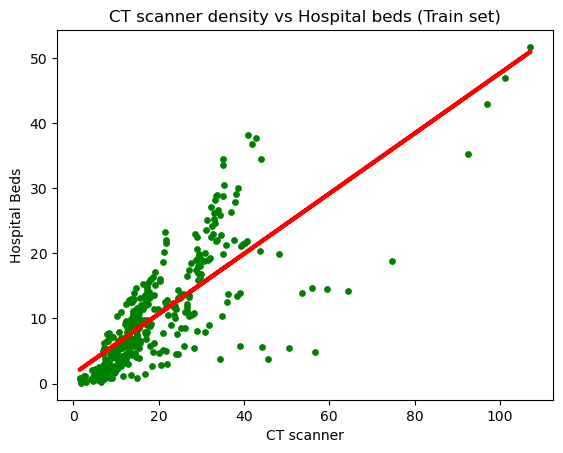

In [78]:
# Visualizing the training set results.

plot_test = plt
plot_test.scatter(X_train, y_train, color='green', s = 15)
plot_test.plot(X_train, y_predicted_train, color='red', linewidth =3)
plot_test.title('CT scanner density vs Hospital beds (Train set)')
plot_test.xlabel('CT scanner')
plot_test.ylabel('Hospital Beds')
plot_test.show()

## bonus: performance improvment after removing outliers

In [49]:
# Clean the extreme values from the "Price per Unit" variable observed during the consistency checks.

df_test = df[df['mri_units'] <=100] 

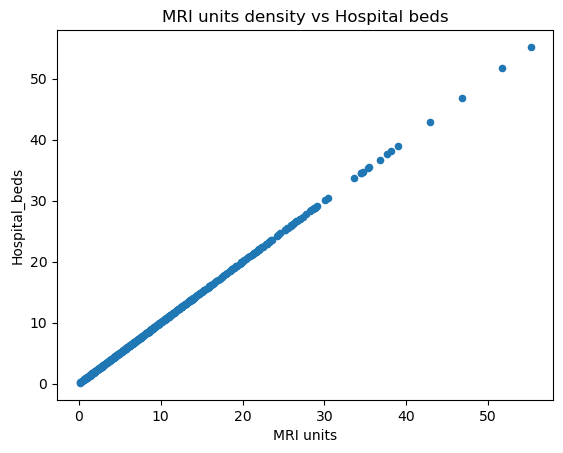

In [55]:
# See how the scatterplot looks without outliers.

df_test.plot.scatter(x='mri_units', y='hospital_beds')  
plt.title('MRI units density vs Hospital beds')  
plt.xlabel('MRI units')  
plt.ylabel('Hospital_beds')  
plt.show()

In [ ]:
#export df with only numeric values 
